# We will examine BART route for 2016 and 2017 to answer some questions for officials work in BART and try to build a improvement suggestion.

<img src="https://logodix.com/logo/304825.png" style="width:100%; max-width:1000px;">







Data Analytics Questions 
1) Which BART station is the busiest? 
2) What is the least popular BART route?
3) When is the best time to go to SF from Berkeley if you want to find a seat?
4) Which day of the week is the busiest? How many people take the BART late at night?

Data Science Questions 

5) Question A: Compute the straight line distance between every station 
6) Question B: Build a model that can predict the number of people commuting to work by Bart between any 2 stations:
7) How would you approach that? 
8) What additional data would you need? 
9) How would you want the city or Bart officials to use your data?

Data Preparation Append the two ridership files for 2016 and 2017 Merge the station data file Answer data analytics questions

In [1]:
import pandas as pd

df16 = pd.read_csv('/kaggle/input/bart-ridership/date-hour-soo-dest-2016.csv')
df17 = pd.read_csv('/kaggle/input/bart-ridership/date-hour-soo-dest-2017.csv')
stations = pd.read_csv('/kaggle/input/bart-ridership/station_info.csv')
df16.tail()


,Origin,Destination,Throughput,DateTime
9971577,WOAK,PLZA,1,2016-12-31 23:00:00
9971578,WOAK,POWL,30,2016-12-31 23:00:00
9971579,WOAK,RICH,2,2016-12-31 23:00:00
9971580,WOAK,ROCK,2,2016-12-31 23:00:00
9971581,WOAK,WOAK,1,2016-12-31 23:00:00


In [2]:
df17.tail()

,Origin,Destination,Throughput,DateTime
3313620,WSPR,MONT,1,2017-05-03 23:00:00
3313621,WSPR,NBRK,1,2017-05-03 23:00:00
3313622,WSPR,NCON,1,2017-05-03 23:00:00
3313623,WSPR,SANL,2,2017-05-03 23:00:00
3313624,WSPR,SHAY,4,2017-05-03 23:00:00


In [3]:
df = pd.concat([df16, df17], ignore_index=True)

In [4]:
df.tail()

,Origin,Destination,Throughput,DateTime
13285202,WSPR,MONT,1,2017-05-03 23:00:00
13285203,WSPR,NBRK,1,2017-05-03 23:00:00
13285204,WSPR,NCON,1,2017-05-03 23:00:00
13285205,WSPR,SANL,2,2017-05-03 23:00:00
13285206,WSPR,SHAY,4,2017-05-03 23:00:00


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13285207 entries, 0 to 13285206
Data columns (total 4 columns):
 #   Column       Dtype 
---  ------       ----- 
 0   Origin       object
 1   Destination  object
 2   Throughput   int64 
 3   DateTime     object
dtypes: int64(1), object(3)
memory usage: 405.4+ MB


In [6]:
# 1) Real DateTime Transformation
df['DateTime'] = pd.to_datetime(df['DateTime'], errors='coerce')


In [7]:
df['Hour'] = df['DateTime'].dt.hour
df['DayOfWeek'] = df['DateTime'].dt.day_name()
df['Month'] = df['DateTime'].dt.month
df['IsWeekend'] = df['DayOfWeek'].isin(['Saturday','Sunday'])
df['Period'] = pd.cut(df['Hour'],
                      bins=[0,5,10,16,20,24],
                      labels=['LateNight','Morning','Midday','Evening','Night'],
                      right=False)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13285207 entries, 0 to 13285206
Data columns (total 9 columns):
 #   Column       Dtype         
---  ------       -----         
 0   Origin       object        
 1   Destination  object        
 2   Throughput   int64         
 3   DateTime     datetime64[ns]
 4   Hour         int32         
 5   DayOfWeek    object        
 6   Month        int32         
 7   IsWeekend    bool          
 8   Period       category      
dtypes: bool(1), category(1), datetime64[ns](1), int32(2), int64(1), object(3)
memory usage: 633.5+ MB


In [9]:
df.tail()

,Origin,Destination,Throughput,DateTime,Hour,DayOfWeek,Month,IsWeekend,Period
13285202,WSPR,MONT,1,2017-05-03 23:00:00,23,Wednesday,5,False,Night
13285203,WSPR,NBRK,1,2017-05-03 23:00:00,23,Wednesday,5,False,Night
13285204,WSPR,NCON,1,2017-05-03 23:00:00,23,Wednesday,5,False,Night
13285205,WSPR,SANL,2,2017-05-03 23:00:00,23,Wednesday,5,False,Night
13285206,WSPR,SHAY,4,2017-05-03 23:00:00,23,Wednesday,5,False,Night


In [10]:
df16.isnull().sum()

Origin         0
Destination    0
Throughput     0
DateTime       0
dtype: int64

In [11]:
df17.isnull().sum()

Origin         0
Destination    0
Throughput     0
DateTime       0
dtype: int64

In [12]:
df.isnull().sum()

Origin         0
Destination    0
Throughput     0
DateTime       0
Hour           0
DayOfWeek      0
Month          0
IsWeekend      0
Period         0
dtype: int64

In [13]:
stations.head()

,Abbreviation,Description,Location,Name
0,12TH,"1245 Broadway, Oakland CA 94612<br />12th St. ...","-122.271450,37.803768,0",12th St. Oakland City Center (12TH)
1,16TH,"2000 Mission Street, San Francisco CA 94110<br...","-122.419694,37.765062,0",16th St. Mission (16TH)
2,19TH,"1900 Broadway, Oakland CA 94612<br />19th Stre...","-122.268602,37.808350,0",19th St. Oakland (19TH)
3,24TH,"2800 Mission Street, San Francisco CA 94110<br...","-122.418143,37.752470,0",24th St. Mission (24TH)
4,ASHB,"3100 Adeline Street, Berkeley CA 94703<br />As...","-122.270062,37.852803,0",Ashby (ASHB)


In [14]:
stations['Abbreviation'].unique()

array(['12TH', '16TH', '19TH', '24TH', 'ASHB', 'BALB', 'BAYF', 'CAST',
       'CIVC', 'COLS', 'COLM', 'CONC', 'DALY', 'DBRK', 'DELN', 'DUBL',
       'EMBR', 'FRMT', 'FTVL', 'GLEN', 'HAYW', 'LAFY', 'LAKE', 'MCAR',
       'MLBR', 'MONT', 'NBRK', 'NCON', 'OAKL', 'ORIN', 'PHIL', 'PITT',
       'PLZA', 'POWL', 'RICH', 'ROCK', 'SANL', 'SBRN', 'SFIA', 'SHAY',
       'SSAN', 'UCTY', 'WARM', 'WCRK', 'WDUB', 'WOAK'], dtype=object)

### Control of any unmatched value within df and stations files.

In [15]:
missing_origin = df[~df['Origin'].isin(stations['Abbreviation'])]['Origin'].unique()
missing_origin

array(['WSPR'], dtype=object)

In [16]:
missing_dest = df[~df['Destination'].isin(stations['Abbreviation'])]['Destination'].unique()
missing_dest

array(['WSPR'], dtype=object)

In [17]:
# We are adding this WSPR station to our stations folder.
# Koordinatlar: 37.502171, -121.939317 (Warm Springs / South Fremont)

new_station = pd.DataFrame({
    'Abbreviation': ['WSPR'],
    'Description': ['Warm Springs / South Fremont'],
    'Location': ['-121.939317,37.502171'],
    'Name': ['Warm Springs / South Fremont']
})


stations = pd.concat([stations, new_station], ignore_index=True)


# Now we can make merge to our data.

In [18]:
stations['Abbreviation'].unique()

array(['12TH', '16TH', '19TH', '24TH', 'ASHB', 'BALB', 'BAYF', 'CAST',
       'CIVC', 'COLS', 'COLM', 'CONC', 'DALY', 'DBRK', 'DELN', 'DUBL',
       'EMBR', 'FRMT', 'FTVL', 'GLEN', 'HAYW', 'LAFY', 'LAKE', 'MCAR',
       'MLBR', 'MONT', 'NBRK', 'NCON', 'OAKL', 'ORIN', 'PHIL', 'PITT',
       'PLZA', 'POWL', 'RICH', 'ROCK', 'SANL', 'SBRN', 'SFIA', 'SHAY',
       'SSAN', 'UCTY', 'WARM', 'WCRK', 'WDUB', 'WOAK', 'WSPR'],
      dtype=object)

In [19]:
# Merging Origin stations value
df = df.merge(stations,left_on='Origin',right_on='Abbreviation',how='left',suffixes=('', '_origin'))

# Merging Destination stations value
df = df.merge(stations,left_on='Destination',right_on='Abbreviation',how='left',suffixes=('', '_dest'))


In [20]:
df.tail()

,Origin,Destination,Throughput,DateTime,Hour,DayOfWeek,Month,IsWeekend,Period,Abbreviation,Description,Location,Name,Abbreviation_dest,Description_dest,Location_dest,Name_dest
13285202,WSPR,MONT,1,2017-05-03 23:00:00,23,Wednesday,5,False,Night,WSPR,Warm Springs / South Fremont,"-121.939317,37.502171",Warm Springs / South Fremont,MONT,"598 Market Street, San Francisco CA 94104<br /...","-122.401066,37.789405,0",Montgomery St. (MONT)
13285203,WSPR,NBRK,1,2017-05-03 23:00:00,23,Wednesday,5,False,Night,WSPR,Warm Springs / South Fremont,"-121.939317,37.502171",Warm Springs / South Fremont,NBRK,"1750 Sacramento Street, Berkeley CA 94702<br /...","-122.283440,37.873967,0",North Berkeley (NBRK)
13285204,WSPR,NCON,1,2017-05-03 23:00:00,23,Wednesday,5,False,Night,WSPR,Warm Springs / South Fremont,"-121.939317,37.502171",Warm Springs / South Fremont,NCON,"3700 Port Chicago Highway, Concord CA 94520<br...","-122.024653,38.003193,0",North Concord/Martinez (NCON)
13285205,WSPR,SANL,2,2017-05-03 23:00:00,23,Wednesday,5,False,Night,WSPR,Warm Springs / South Fremont,"-121.939317,37.502171",Warm Springs / South Fremont,SANL,"1401 San Leandro Blvd., San Leandro CA 94577<b...","-122.160844,37.721947,0",San Leandro (SANL)
13285206,WSPR,SHAY,4,2017-05-03 23:00:00,23,Wednesday,5,False,Night,WSPR,Warm Springs / South Fremont,"-121.939317,37.502171",Warm Springs / South Fremont,SHAY,"28601 Dixon Street, Hayward CA 94544<br />Hayw...","-122.057189,37.634375,0",South Hayward (SHAY)


In [21]:
df = df.drop(columns=['Abbreviation', 'Abbreviation_dest'])
# merge sutunlarindan sonra bu mukerrer sutunlara gerek kalmadi

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13285207 entries, 0 to 13285206
Data columns (total 15 columns):
 #   Column            Dtype         
---  ------            -----         
 0   Origin            object        
 1   Destination       object        
 2   Throughput        int64         
 3   DateTime          datetime64[ns]
 4   Hour              int32         
 5   DayOfWeek         object        
 6   Month             int32         
 7   IsWeekend         bool          
 8   Period            category      
 9   Description       object        
 10  Location          object        
 11  Name              object        
 12  Description_dest  object        
 13  Location_dest     object        
 14  Name_dest         object        
dtypes: bool(1), category(1), datetime64[ns](1), int32(2), int64(1), object(9)
memory usage: 1.2+ GB


#### Top 10 Origin Stations

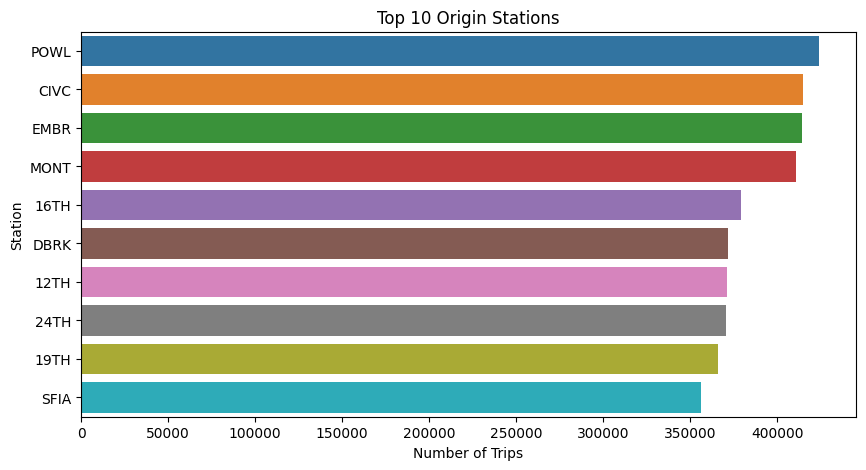

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

top_origins = df['Origin'].value_counts().head(10)
plt.figure(figsize=(10,5))
sns.barplot(x=top_origins.values, y=top_origins.index)
plt.title("Top 10 Origin Stations")
plt.xlabel("Number of Trips")
plt.ylabel("Station")
plt.show()

#### Top 10 Destination Stations

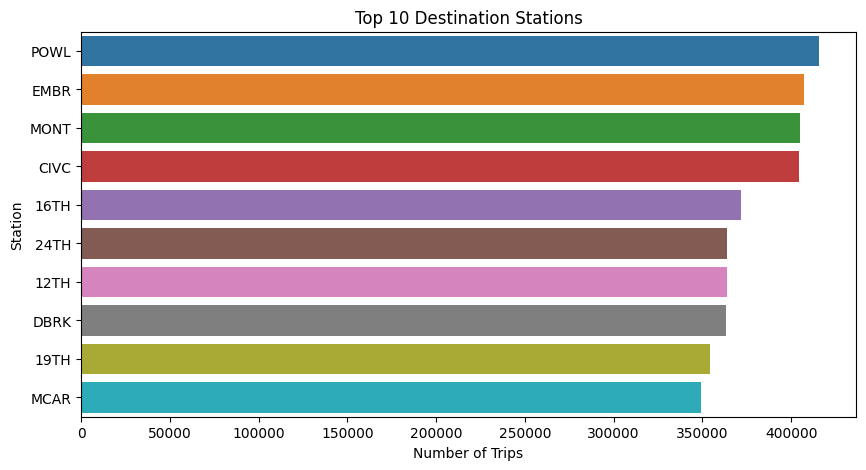

In [24]:
top_dest = df['Destination'].value_counts().head(10)
plt.figure(figsize=(10,5))
sns.barplot(x=top_dest.values, y=top_dest.index)
plt.title("Top 10 Destination Stations")
plt.xlabel("Number of Trips")
plt.ylabel("Station")
plt.show()


### 1-) Which Bart Station is the busiest?

In [25]:
station_loads = (df.groupby('Origin')['Throughput'].sum() +
                 df.groupby('Destination')['Throughput'].sum())
station_loads.sort_values(ascending=False).head(10)


Origin
EMBR    34076644
MONT    33063895
POWL    26593039
CIVC    19536703
DBRK    10806360
24TH    10762588
16TH    10749505
12TH    10714765
19TH    10392910
BALB     9070671
Name: Throughput, dtype: int64

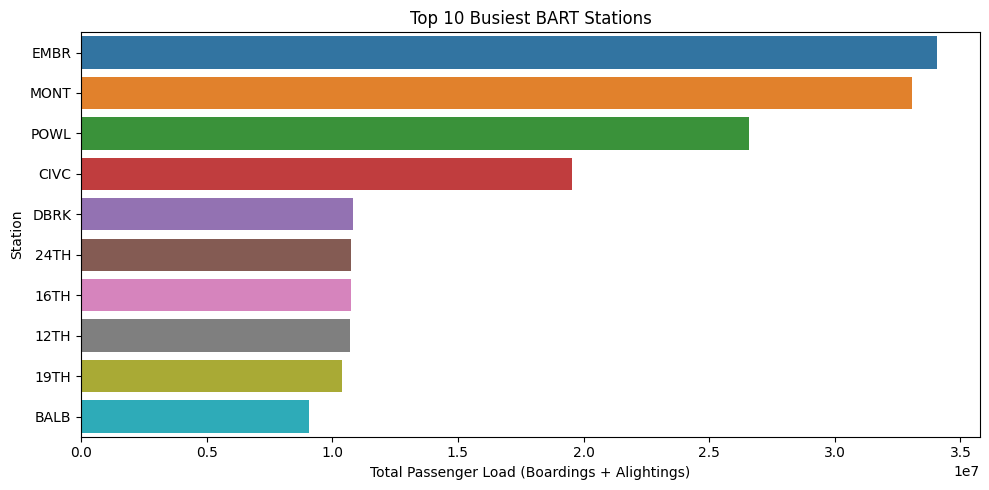

In [26]:
top10 = station_loads.sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=top10.values, y=top10.index)

plt.title("Top 10 Busiest BART Stations")
plt.xlabel("Total Passenger Load (Boardings + Alightings)")
plt.ylabel("Station")

plt.tight_layout()
plt.show()


##### EMBR station is the busiest station in BART system.

### 2-)Which is the least popular route?

In [27]:
df.groupby(['Origin', 'Destination'])['Throughput'].sum().idxmin()

('WSPR', 'SBRN')

In [28]:
df.groupby(['Origin', 'Destination'])['Throughput'].sum().idxmax()

('POWL', 'BALB')

In [29]:
least_routes = (
    df.groupby(['Origin', 'Destination'])['Throughput']
      .sum()
      .sort_values()
      .head(10)
)

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)


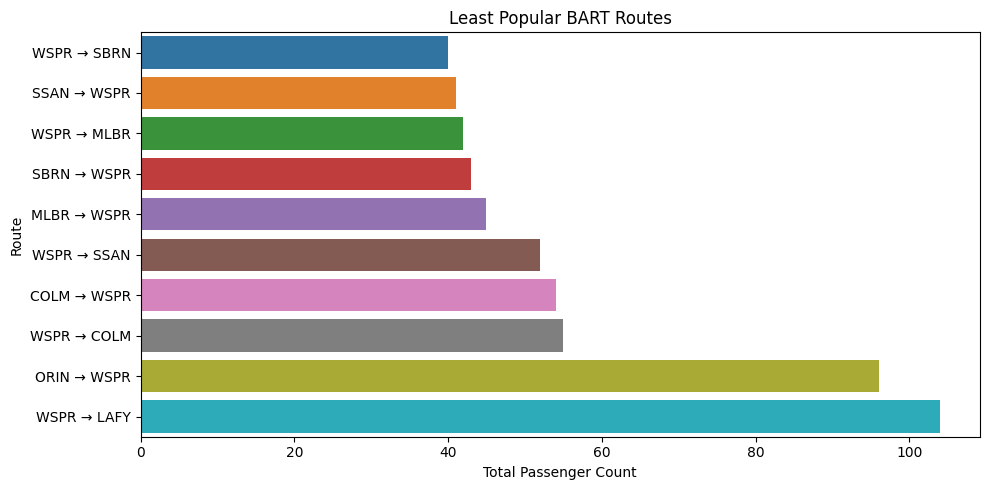

In [30]:
plt.figure(figsize=(10, 5))
sns.barplot(x=least_routes.values,
            y=[f"{o} → {d}" for o, d in least_routes.index])

plt.title("Least Popular BART Routes")
plt.xlabel("Total Passenger Count")
plt.ylabel("Route")

plt.tight_layout()
plt.show()


##### The least popular route is to SBRN from WSPR

### 3-)Which day of the week is the busiest?

In [31]:
df.groupby('DayOfWeek')['Throughput'].sum().sort_values(ascending=False)

DayOfWeek
Wednesday    30677189
Tuesday      30350159
Thursday     30049974
Friday       28373709
Monday       26967803
Saturday     13696288
Sunday        9602140
Name: Throughput, dtype: int64

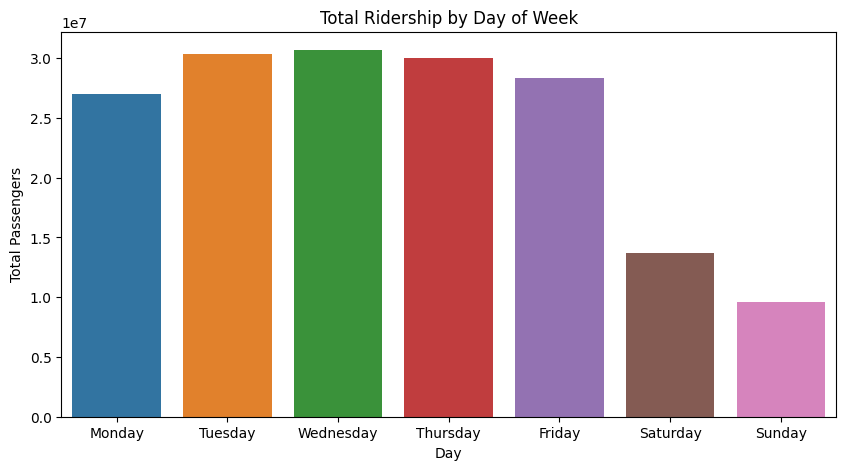

In [32]:
day_load = df.groupby('DayOfWeek')['Throughput'].sum().reindex(
    ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
)

plt.figure(figsize=(10,5))
sns.barplot(x=day_load.index, y=day_load.values)
plt.title("Total Ridership by Day of Week")
plt.ylabel("Total Passengers")
plt.xlabel("Day")
plt.show()


##### Wednesday is the busiest day of the week

### 4-) How many people take the BART late at night?

In [33]:
late_night_riders = df[df['Period'] == 'LateNight']['Throughput'].sum()
late_night_riders

2085357

/tmp/ipykernel_47/1477432320.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  period_counts = df.groupby('Period')['Throughput'].sum()


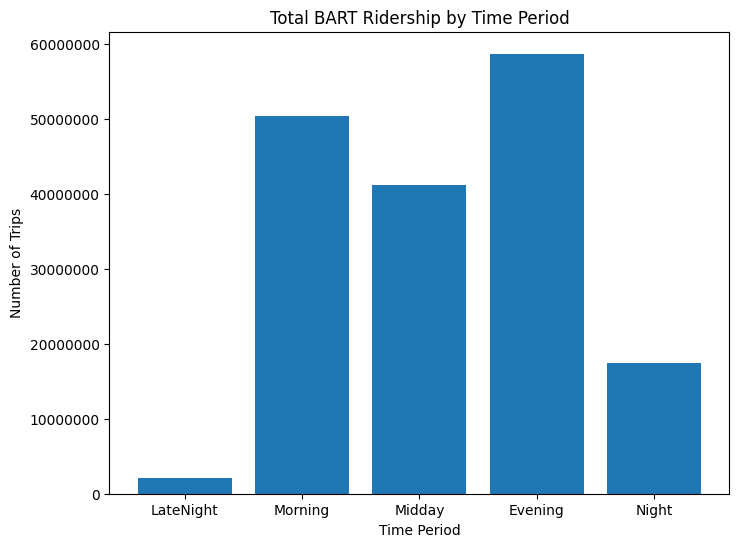

In [34]:
period_counts = df.groupby('Period')['Throughput'].sum()
plt.figure(figsize=(8,6))
plt.bar(period_counts.index, period_counts.values)

plt.title("Total BART Ridership by Time Period")
plt.xlabel("Time Period")
plt.ylabel("Number of Trips")

plt.ticklabel_format(style='plain', axis='y')  # <-- scientific notation KAPATIR
plt.show()

/tmp/ipykernel_47/4261892059.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  period_counts = df.groupby('Period')['Throughput'].sum()


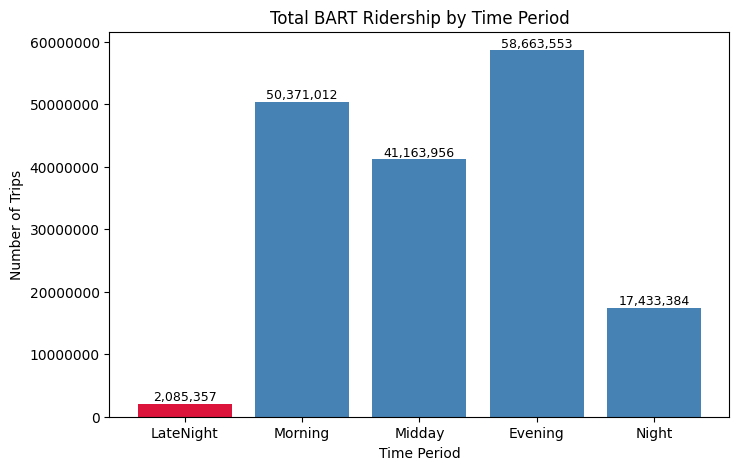

In [35]:
period_counts = df.groupby('Period')['Throughput'].sum()

colors = ['crimson' if p == 'LateNight' else 'steelblue' 
          for p in period_counts.index]

plt.figure(figsize=(8,5))
bars = plt.bar(period_counts.index, period_counts.values, color=colors)

plt.title("Total BART Ridership by Time Period")
plt.xlabel("Time Period")
plt.ylabel("Number of Trips")
plt.ticklabel_format(style='plain', axis='y')

# değerleri yaz
for bar in bars:
    y = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, y,
             f"{int(y):,}", ha='center', va='bottom', fontsize=9)

plt.show()


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


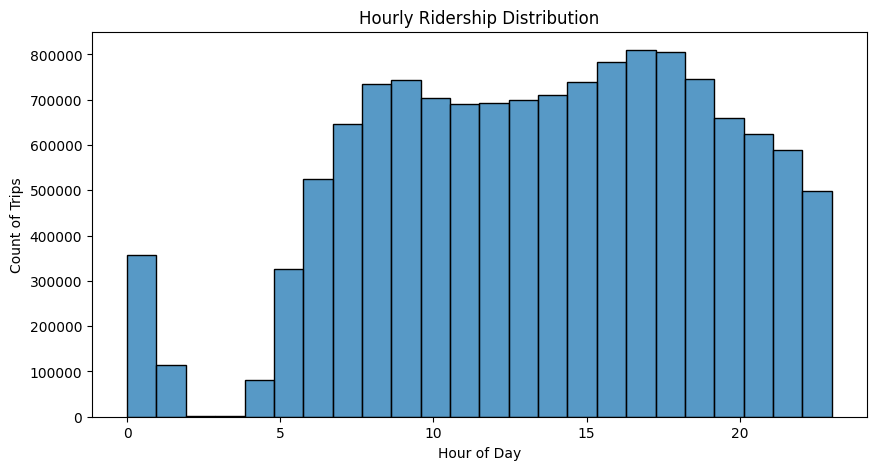

In [36]:
plt.figure(figsize=(10,5))
sns.histplot(df['Hour'], bins=24, kde=False)
plt.title("Hourly Ridership Distribution")
plt.xlabel("Hour of Day")
plt.ylabel("Count of Trips")
plt.show()

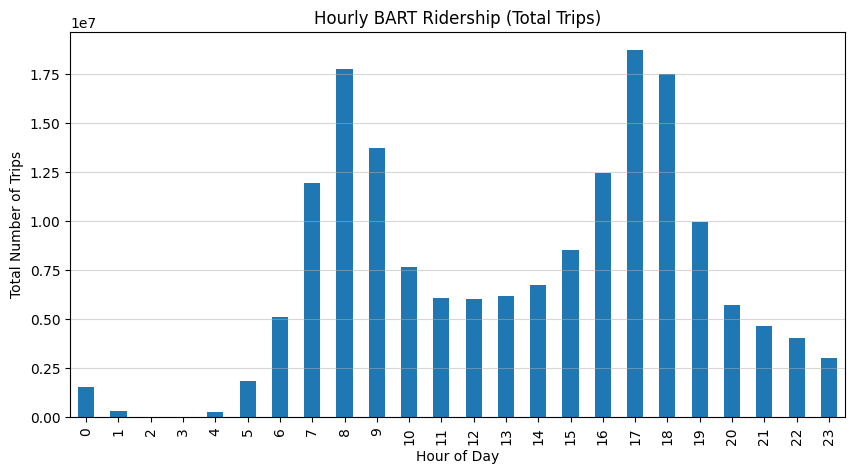

In [37]:
hourly_trips = df.groupby('Hour')['Throughput'].sum()

plt.figure(figsize=(10,5))
hourly_trips.plot(kind='bar')
plt.title("Hourly BART Ridership (Total Trips)")
plt.xlabel("Hour of Day")
plt.ylabel("Total Number of Trips")
plt.grid(axis='y', alpha=0.5)
plt.show()


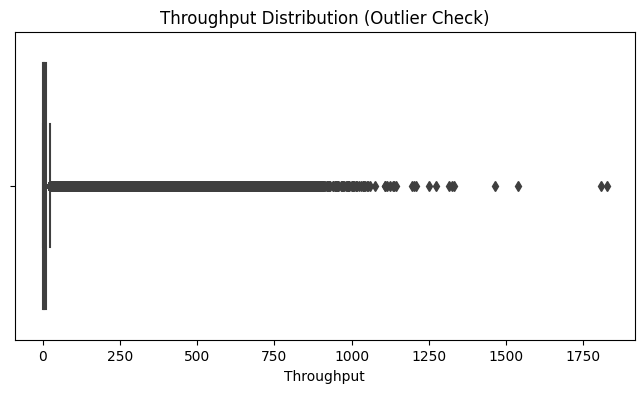

In [38]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df['Throughput'])
plt.title("Throughput Distribution (Outlier Check)")
plt.show()

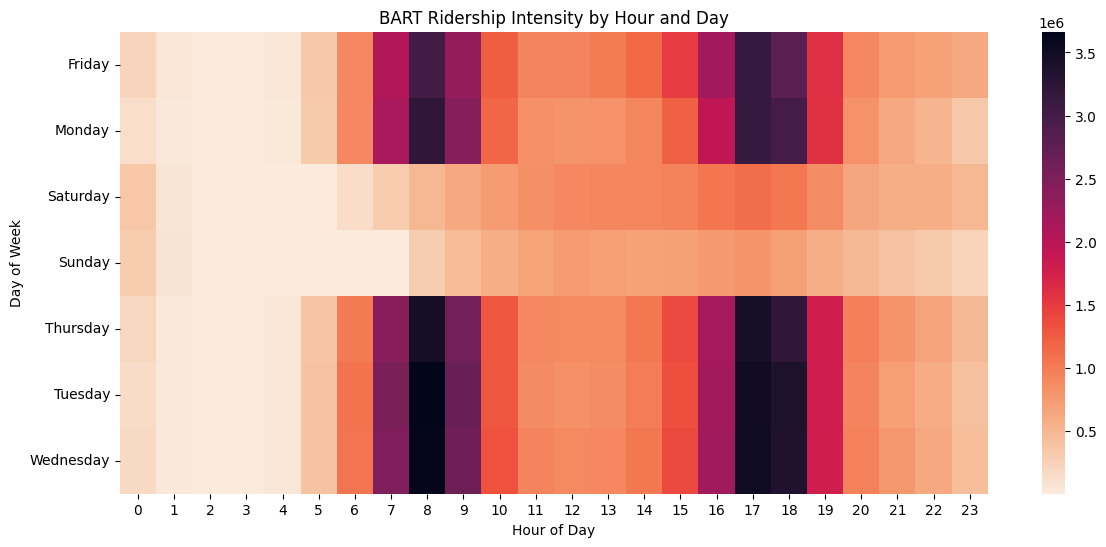

In [39]:
pivot = df.pivot_table(
    values='Throughput',
    index='DayOfWeek',
    columns='Hour',
    aggfunc='sum'
)

plt.figure(figsize=(14,6))
sns.heatmap(pivot, cmap='rocket_r')
plt.title("BART Ridership Intensity by Hour and Day")
plt.xlabel("Hour of Day")
plt.ylabel("Day of Week")
plt.show()


#### 5-) Popular Routes

In [40]:
top_routes = df.groupby(['Origin','Destination'])['Throughput'].sum().sort_values(ascending=False).head(10)
top_routes

Origin  Destination
POWL    BALB           1105884
BALB    MONT           1013860
        POWL            938212
POWL    24TH            913309
DUBL    EMBR            901632
24TH    MONT            898585
FRMT    EMBR            810277
24TH    POWL            789335
WOAK    EMBR            788083
MONT    24TH            774595
Name: Throughput, dtype: int64

In [41]:
df.head(3)

,Origin,Destination,Throughput,DateTime,Hour,DayOfWeek,Month,IsWeekend,Period,Description,Location,Name,Description_dest,Location_dest,Name_dest
0,12TH,12TH,1,2016-01-01,0,Friday,1,False,LateNight,"1245 Broadway, Oakland CA 94612<br />12th St. ...","-122.271450,37.803768,0",12th St. Oakland City Center (12TH),"1245 Broadway, Oakland CA 94612<br />12th St. ...","-122.271450,37.803768,0",12th St. Oakland City Center (12TH)
1,12TH,16TH,1,2016-01-01,0,Friday,1,False,LateNight,"1245 Broadway, Oakland CA 94612<br />12th St. ...","-122.271450,37.803768,0",12th St. Oakland City Center (12TH),"2000 Mission Street, San Francisco CA 94110<br...","-122.419694,37.765062,0",16th St. Mission (16TH)
2,12TH,24TH,4,2016-01-01,0,Friday,1,False,LateNight,"1245 Broadway, Oakland CA 94612<br />12th St. ...","-122.271450,37.803768,0",12th St. Oakland City Center (12TH),"2800 Mission Street, San Francisco CA 94110<br...","-122.418143,37.752470,0",24th St. Mission (24TH)


In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13285207 entries, 0 to 13285206
Data columns (total 15 columns):
 #   Column            Dtype         
---  ------            -----         
 0   Origin            object        
 1   Destination       object        
 2   Throughput        int64         
 3   DateTime          datetime64[ns]
 4   Hour              int32         
 5   DayOfWeek         object        
 6   Month             int32         
 7   IsWeekend         bool          
 8   Period            category      
 9   Description       object        
 10  Location          object        
 11  Name              object        
 12  Description_dest  object        
 13  Location_dest     object        
 14  Name_dest         object        
dtypes: bool(1), category(1), datetime64[ns](1), int32(2), int64(1), object(9)
memory usage: 1.2+ GB


#### Transform of some columns to category, since they have the same values. like day and station to protect our model and also our RAM.

In [43]:
cat_cols = ['DayOfWeek', 'Origin', 'Destination']
for c in cat_cols:
    df[c] = df[c].astype('category')

In [44]:
df[['lon_origin','lat_origin','alt1']] = df['Location'].str.split(',', expand=True).astype(float)
df[['lon_dest','lat_dest','alt2']] = df['Location_dest'].str.split(',', expand=True).astype(float)


In [45]:
df = df.drop(columns=['alt1','alt2'])

In [46]:
df = df.drop(columns=['Description', 'Description_dest']) 
# koordinat bilgilerini aldik duseriz.
df = df.drop(columns=['Name','Name_dest'])
# istasyon isimlerini de origin ve destination sutunlarindan aldigimiz icin duseriz.

In [47]:
df= df.drop(columns=['Location', 'Location_dest'])

In [48]:
df.head(3)

,Origin,Destination,Throughput,DateTime,Hour,DayOfWeek,Month,IsWeekend,Period,lon_origin,lat_origin,lon_dest,lat_dest
0,12TH,12TH,1,2016-01-01,0,Friday,1,False,LateNight,-122.27145,37.803768,-122.271450,37.803768
1,12TH,16TH,1,2016-01-01,0,Friday,1,False,LateNight,-122.27145,37.803768,-122.419694,37.765062
2,12TH,24TH,4,2016-01-01,0,Friday,1,False,LateNight,-122.27145,37.803768,-122.418143,37.752470


In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13285207 entries, 0 to 13285206
Data columns (total 13 columns):
 #   Column       Dtype         
---  ------       -----         
 0   Origin       category      
 1   Destination  category      
 2   Throughput   int64         
 3   DateTime     datetime64[ns]
 4   Hour         int32         
 5   DayOfWeek    category      
 6   Month        int32         
 7   IsWeekend    bool          
 8   Period       category      
 9   lon_origin   float64       
 10  lat_origin   float64       
 11  lon_dest     float64       
 12  lat_dest     float64       
dtypes: bool(1), category(4), datetime64[ns](1), float64(4), int32(2), int64(1)
memory usage: 772.9 MB


### 6-) When is the best time to go to SF from Berkeley if you want to find a seat?

##### “Using spatial filtering based on geographic coordinates, all Berkeley-origin and San Francisco-destination stations were identified without manual station selection."

In [50]:
berkeley_stations = (
    df[
        (df['lat_origin'].between(37.85, 37.89)) &
        (df['lon_origin'].between(-122.28, -122.25))
    ]['Origin']
    .unique()
)

berkeley_stations

['ASHB', 'DBRK']
Categories (46, object): ['12TH', '16TH', '19TH', '24TH', ..., 'WCRK', 'WDUB', 'WOAK', 'WSPR']

In [51]:
sf_stations = (
    df[
        (df['lat_dest'].between(37.70, 37.81)) &
        (df['lon_dest'].between(-122.52, -122.36))
    ]['Destination']
    .unique()
)

sf_stations


['16TH', '24TH', 'BALB', 'CIVC', 'EMBR', 'MONT', 'POWL', 'DALY', 'GLEN']
Categories (46, object): ['12TH', '16TH', '19TH', '24TH', ..., 'WCRK', 'WDUB', 'WOAK', 'WSPR']

In [52]:
subset = df[
df['Origin'].isin(berkeley_stations) &(df['Destination'].isin(sf_stations))]

In [53]:
subset.groupby('Hour')['Throughput'].mean()

Hour
0      4.887673
1      2.318634
2      3.387097
3      1.937500
4      1.521028
5      4.423778
6     11.134634
7     30.479479
8     59.355066
9     57.600696
10    29.670653
11    21.648000
12    19.966178
13    18.401491
14    17.393239
15    16.665733
16    17.967112
17    25.938918
18    26.676440
19    17.754266
20    10.149850
21     9.090920
22     8.846232
23     7.450000
Name: Throughput, dtype: float64

##### The average hourly throughput between Berkeley-origin and San Francisco-destination stations was computed. The lowest average throughput occurs at 04:00, indicating the most favorable time for passengers seeking seat availability, while peak congestion is observed between 08:00 and 09:00.

In [54]:
subset[subset['Period'] == 'Evening'].groupby('Hour')['Throughput'].mean().idxmin()


19

#### Which time is more suitable to find a seat while going back home from work in Evening Period

In [55]:
daytime_subset = subset[subset['Hour'].between(6,21)]

In [56]:
hourly_mean = daytime_subset.groupby('Hour')['Throughput'].mean()
hourly_mean

Hour
6     11.134634
7     30.479479
8     59.355066
9     57.600696
10    29.670653
11    21.648000
12    19.966178
13    18.401491
14    17.393239
15    16.665733
16    17.967112
17    25.938918
18    26.676440
19    17.754266
20    10.149850
21     9.090920
Name: Throughput, dtype: float64

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


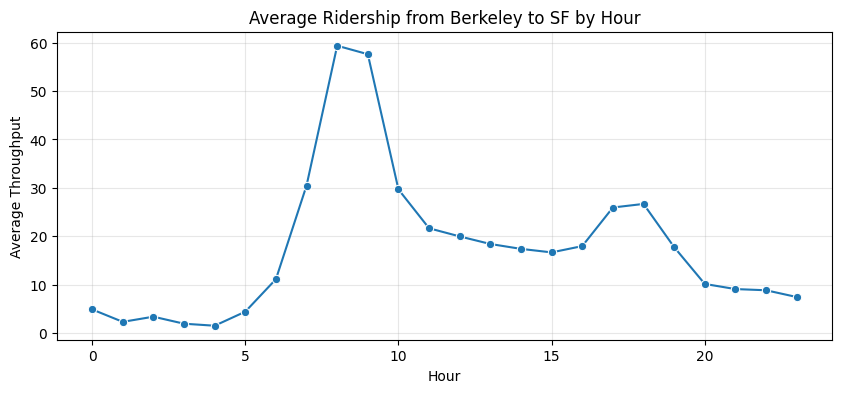

In [57]:
subset = df[
    df['Origin'].isin(berkeley_stations) &
    df['Destination'].isin(sf_stations)
]


hourly_mean = subset.groupby('Hour')['Throughput'].mean()

plt.figure(figsize=(10,4))
sns.lineplot(x=hourly_mean.index, y=hourly_mean.values, marker='o')
plt.title("Average Ridership from Berkeley to SF by Hour")
plt.xlabel("Hour")
plt.ylabel("Average Throughput")
plt.grid(alpha=0.3)
plt.show()


##### yukarida hem SF hem de Berkeley istasyonlarini al demis olduk, ve operatoru de kullandik aralarinda. tek bir istasyon secmez, mantiksal bir filtre uretir bizim icin.

#### Hourly and spatial analysis reveals that BART ridership is highly concentrated during weekday peak hours on a small number of short-distance routes, while late-night and off-peak travel exhibits consistently low demand, offering optimal conditions for seat availability.

### 7-) Question A - Distance_km 

In [58]:
import numpy as np

# Fonksiyonu tanımla (Matematiksel formül - Bunu değiştirmene gerek yok)
def get_distance(lat1, lon1, lat2, lon2):
    
    R = 6371  # Dünya yarıçapı (km)
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlambda = np.radians(lon2 - lon1)
    a = np.sin(dphi/2)**2 + np.cos(phi1)*np.cos(phi2)*np.sin(dlambda/2)**2
    return R * 2 * np.arctan2(np.sqrt(a), np.sqrt(1-a))



In [59]:

# Bu işlem tüm 13 milyon satır için mesafeyi hesaplayıp yeni sütuna yazar

df['dist_km'] = get_distance(df['lat_origin'], df['lon_origin'], df['lat_dest'], df['lon_dest'])

# Kontrol et
df[['Origin', 'Destination', 'dist_km']]

,Origin,Destination,dist_km
0,12TH,12TH,0.000000
1,12TH,16TH,13.720175
2,12TH,24TH,14.097927
3,12TH,ASHB,5.453806
4,12TH,BALB,17.972899
...,...,...,...
13285202,WSPR,MONT,51.699745
13285203,WSPR,NBRK,51.245150
13285204,WSPR,NCON,56.214002
13285205,WSPR,SANL,31.272551


In [60]:
# Mesafeye göre Büyükten -> Küçüğe sıralanmış referans tablosu
unique_distances = df[['Origin', 'Destination', 'dist_km']]\
                     .drop_duplicates()\
                     .sort_values(by='dist_km', ascending=False)\
                     .reset_index(drop=True)

unique_distances.head(30) 

,Origin,Destination,dist_km
0,MLBR,PITT,60.593970
1,PITT,MLBR,60.593970
2,WSPR,RICH,60.504476
3,RICH,WSPR,60.504476
4,PITT,SFIA,59.590371
5,SFIA,PITT,59.590371
6,SBRN,PITT,59.231845
7,PITT,SBRN,59.231845
8,COLM,PITT,58.946439
9,PITT,COLM,58.946439


# Modelling

#### Question B

In [61]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13285207 entries, 0 to 13285206
Data columns (total 14 columns):
 #   Column       Dtype         
---  ------       -----         
 0   Origin       category      
 1   Destination  category      
 2   Throughput   int64         
 3   DateTime     datetime64[ns]
 4   Hour         int32         
 5   DayOfWeek    category      
 6   Month        int32         
 7   IsWeekend    bool          
 8   Period       category      
 9   lon_origin   float64       
 10  lat_origin   float64       
 11  lon_dest     float64       
 12  lat_dest     float64       
 13  dist_km      float64       
dtypes: bool(1), category(4), datetime64[ns](1), float64(5), int32(2), int64(1)
memory usage: 874.2 MB


In [61]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

In [62]:
# 1. KATEGORİLERİ SAYIYA ÇEVİRME (En Hızlı Yöntem)

# Pandas'ın "cat.codes" özelliği, kategori isimlerini 0,1,2 gibi sayılara çevirir.
# Bunu yapmazsak Scikit-Learn hata verir.

df['Origin_Code'] = df['Origin'].cat.codes
df['Dest_Code'] = df['Destination'].cat.codes
df['Day_Code'] = df['DayOfWeek'].cat.codes
df['Period_Code'] = df['Period'].cat.codes

In [230]:
# 2. SAMPLING (Örnekleme) - ÇOK ÖNEMLİ!
# 13 Milyon satırı Random Forest'a sokarsan RAM yetmeyebilir veya saatlerce sürer.
# Profesyonel dünyada önce %5-%10'luk veriyle model denenir.

df_sample = df.sample(frac=0.05, random_state=42) # %8'ini alıyoruz

In [231]:

# 3. GİRDİLERİ SEÇME
# Artık her şey sayısal formatta, model bunu yiyebilir.
# modele lon ve lan bilgileri vermeyiz asiri gurultu olur modele anlam katmaz. zaten origin_code ve dest_code
features = ['Hour', 'Month', 'dist_km', 'Origin_Code', 'Dest_Code', 'Day_Code', 'Period_Code', 'IsWeekend']
target = 'Throughput'

x = df_sample[features]
y = df_sample[target]

In [232]:

# 4. EĞİTİM VE TEST AYRIMI
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [233]:
# 5. MODELİ EĞİTME

model = RandomForestRegressor(n_estimators=50, max_depth=12, n_jobs=-1, random_state=42)
model.fit(x_train, y_train)

RandomForestRegressor(max_depth=12, n_estimators=50, n_jobs=-1, random_state=42)

In [234]:

# 6. SONUÇLARI GÖRME
preds = model.predict(x_test)
print(f"MAE (Ortalama Hata): {mean_absolute_error(y_test, preds):.2f} yolcu")
print(f"R2 Score (Başarı): {r2_score(y_test, preds):.2f}")

MAE (Ortalama Hata): 6.97 yolcu
R2 Score (Başarı): 0.74


#### 2.test
#### We are increasing our sample size from %5 to %10.

In [235]:
# 2. SAMPLING (Örnekleme) - ÇOK ÖNEMLİ!
# 13 Milyon satırı Random Forest'a sokarsan RAM yetmeyebilir veya saatlerce sürer.
# Profesyonel dünyada önce %5-%10'luk veriyle model denenir.

df_sample_v2 = df.sample(frac=0.1, random_state=42) # %10'ini alıyoruz

In [236]:
x_v2 = df_sample_v2[features]
y_v2 = df_sample_v2[target]

In [237]:
x_train_v2, x_test_v2, y_train_v2, y_test_v2 = train_test_split(x_v2, y_v2, test_size=0.2, random_state=42)

In [238]:
model_v2 = RandomForestRegressor(n_estimators=100, max_depth=25, min_samples_leaf=2, n_jobs=-1, random_state=42)


In [239]:
model_v2.fit(x_train_v2, y_train_v2)

RandomForestRegressor(max_depth=25, min_samples_leaf=2, n_jobs=-1,
                      random_state=42)

In [242]:
preds_v2 = model_v2.predict(x_test_v2)

print(f"MAE (Ortalama Hata): {mean_absolute_error(y_test_v2, preds_v2):.2f} yolcu")
print(f"R2 Score (Başarı): {r2_score(y_test_v2, preds_v2):.2f}")

MAE (Ortalama Hata): 3.58 yolcu
R2 Score (Başarı): 0.90


##### our decision for choosing parametres is important right here. max_depth=25 and n_estimators=100 could be useful for model

#### 3.test

In [251]:
df_sample_v3 = df.sample(frac=0.2, random_state=42) # %20'ini alıyoruz

In [252]:
features = ['Hour', 'Month', 'dist_km', 'Origin_Code', 'Dest_Code', 'Day_Code', 'Period_Code', 'IsWeekend']
target = 'Throughput'

x_v3 = df_sample[features]
y_v3 = df_sample[target]

In [253]:
x_train_v3, x_test_v3, y_train_v3, y_test_v3 = train_test_split(x_v3, y_v3, test_size=0.2, random_state=42)

In [254]:
model_v3 = RandomForestRegressor(n_estimators=100, max_depth=25, min_samples_leaf=2, n_jobs=-1, random_state=42)


In [255]:
model_v3.fit(x_train_v3, y_train_v3)

RandomForestRegressor(max_depth=25, min_samples_leaf=2, n_jobs=-1,
                      random_state=42)

In [256]:
preds_v3 = model_v3.predict(x_test_v3)

print(f"MAE (Ortalama Hata): {mean_absolute_error(y_test_v3, preds_v3):.2f} yolcu")
print(f"R2 Score (Başarı): {r2_score(y_test_v3, preds_v3):.2f}")

MAE (Ortalama Hata): 3.69 yolcu
R2 Score (Başarı): 0.90


#### since we found an optimum value for R2, it is not about choosing more samples to get higher r2 now.
### Plateu Effect
#### It is about our model and way of new learning trees.

#### We need to try Gradient Boosting models now. (XGBoost, LightGBM, CatBoost).

### Also we need to know holidays, important sports day, ((lag features)).

In [64]:
import lightgbm as lgb
import holidays


In [65]:

# FEATURE ENGINEERING: ADDING HOLIDAYS 
# California Holidays
us_holidays = holidays.US(state='CA', years=[2016, 2017])

In [66]:
df['IsHoliday'] = df['DateTime'].dt.date.isin(us_holidays).astype(int)

In [262]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13285207 entries, 0 to 13285206
Data columns (total 19 columns):
 #   Column       Dtype         
---  ------       -----         
 0   Origin       category      
 1   Destination  category      
 2   Throughput   int64         
 3   DateTime     datetime64[ns]
 4   Hour         int32         
 5   DayOfWeek    category      
 6   Month        int32         
 7   IsWeekend    bool          
 8   Period       category      
 9   lon_origin   float64       
 10  lat_origin   float64       
 11  lon_dest     float64       
 12  lat_dest     float64       
 13  dist_km      float64       
 14  Origin_Code  int8          
 15  Dest_Code    int8          
 16  Day_Code     int8          
 17  Period_Code  int8          
 18  IsHoliday    int64         
dtypes: bool(1), category(4), datetime64[ns](1), float64(5), int32(2), int64(2), int8(4)
memory usage: 1.0 GB


In [263]:
df.head(3)

,Origin,Destination,Throughput,DateTime,Hour,DayOfWeek,Month,IsWeekend,Period,lon_origin,lat_origin,lon_dest,lat_dest,dist_km,Origin_Code,Dest_Code,Day_Code,Period_Code,IsHoliday
0,12TH,12TH,1,2016-01-01,0,Friday,1,False,LateNight,-122.27145,37.803768,-122.271450,37.803768,0.000000,0,0,0,0,1
1,12TH,16TH,1,2016-01-01,0,Friday,1,False,LateNight,-122.27145,37.803768,-122.419694,37.765062,13.720175,0,1,0,0,1
2,12TH,24TH,4,2016-01-01,0,Friday,1,False,LateNight,-122.27145,37.803768,-122.418143,37.752470,14.097927,0,3,0,0,1


#### 4.test

In [70]:
features = ['Hour', 'Month', 'dist_km', 'Origin_Code', 'Dest_Code', 'Day_Code', 'Period_Code', 'IsWeekend','IsHoliday']
target = 'Throughput'

In [71]:
df_sample_v4 = df.sample(frac=0.1, random_state=42)
x_v4 = df_sample_v4[features]
y_v4 = df_sample_v4['Throughput']

In [72]:
x_train_v4, x_test_v4, y_train_v4, y_test_v4 = train_test_split(x_v4, y_v4, test_size=0.2, random_state=42)

In [73]:
 # LIGHTGBM MODEL 

params = {
    'objective': 'regression',
    'metric': 'mae',
    'boosting_type': 'gbdt',
    'num_leaves': 100,       # Ağaç karmaşıklığı (RF'deki max_depth gibi ama daha zeki)
    'learning_rate': 0.1,    # Öğrenme hızı
    'feature_fraction': 0.9, # Her ağaçta özelliklerin %90'ını kullan
    'n_jobs': -1,            # Tüm işlemcileri kullan
    'random_state': 42,
    'verbose': -1
}

In [74]:
# Veri setini LightGBM formatına çevir
train_data = lgb.Dataset(x_train_v4, label=y_train_v4)
test_data = lgb.Dataset(x_test_v4, label=y_test_v4, reference=train_data)

In [75]:
model_lgb = lgb.train(
    params,
    train_data,
    num_boost_round=1000, # 1000 ağaç (Boosting olduğu için çok sayıda olabilir)
    valid_sets=[test_data],
    callbacks=[lgb.early_stopping(stopping_rounds=50)] # İyileşme durursa eğitimi kes
)

Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[999]	valid_0's l1: 3.65197


In [76]:
preds_lgb = model_lgb.predict(x_test_v4)
print("-" * 30)
print(f"LIGHTGBM MAE: {mean_absolute_error(y_test_v4, preds_lgb):.2f}")
print(f"LIGHTGBM R2 Score: {r2_score(y_test_v4, preds_lgb):.4f}")
print("-" * 30)

------------------------------
LIGHTGBM MAE: 3.65
LIGHTGBM R2 Score: 0.9248
------------------------------


#### 5. test

In [78]:
df_sample_v5 = df.sample(frac=0.2, random_state=42) 

In [79]:
x_v5 = df_sample_v5[features]
y_v5 = df_sample_v5['Throughput']

In [81]:
x_train_v5, x_test_v5, y_train_v5, y_test_v5 = train_test_split(x_v5, y_v5, test_size=0.2, random_state=42)


In [82]:
params = {
    'objective': 'regression',
    'metric': 'mae',
    'boosting_type': 'gbdt',
    'num_leaves': 256,       # DİKKAT: 120'den 256'ya çıktık (Daha karmaşık ilişkileri yakalar)
    'learning_rate': 0.05,   # Hız aynı kalsın, iyiydi
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8, 
    'bagging_freq': 5,
    'n_jobs': -1,            
    'random_state': 42,
    'verbose': -1
}

In [83]:
train_data_v5 = lgb.Dataset(x_train_v5, label=y_train_v5)
test_data_v5 = lgb.Dataset(x_test_v5, label=y_test_v5, reference=train_data_v5)

In [84]:
model_lgb_v5 = lgb.train(
    params,
    train_data_v5,
    num_boost_round=3000,    # 3000 tur yeterli olacaktır (Veri arttığı için her tur daha dolu)
    valid_sets=[test_data_v5],
    callbacks=[lgb.early_stopping(stopping_rounds=100)]
)

Training until validation scores don't improve for 100 rounds
Did not meet early stopping. Best iteration is:
[2985]	valid_0's l1: 3.32265


In [85]:
preds_v5 = model_lgb_v5.predict(x_test_v5)

print("\n" + "="*30)
print(f"FINAL V5 MAE: {mean_absolute_error(y_test_v5, preds_v5):.2f}")
print(f"FINAL V5 R2 Score: {r2_score(y_test_v5, preds_v5):.4f}")
print("="*30)


FINAL V5 MAE: 3.32
FINAL V5 R2 Score: 0.9375


#### 6.test ( Now we are trying %50 of our data for our model to test in big amount of size.

In [88]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import lightgbm as lgb
import holidays

In [89]:
# FEATURE ENGINEERING: ADDING HOLIDAYS 
# California Holidays
us_holidays = holidays.US(state='CA', years=[2016, 2017])

In [90]:
df['IsHoliday'] = df['DateTime'].dt.date.isin(us_holidays).astype(int)

In [91]:
# 1. KATEGORİLERİ SAYIYA ÇEVİRME (En Hızlı Yöntem)

# Pandas'ın "cat.codes" özelliği, kategori isimlerini 0,1,2 gibi sayılara çevirir.
# Bunu yapmazsak Scikit-Learn hata verir.

df['Origin_Code'] = df['Origin'].cat.codes
df['Dest_Code'] = df['Destination'].cat.codes
df['Day_Code'] = df['DayOfWeek'].cat.codes
df['Period_Code'] = df['Period'].cat.codes

In [92]:
features = ['Hour', 'Month', 'dist_km', 'Origin_Code', 'Dest_Code', 'Day_Code', 'Period_Code', 'IsWeekend','IsHoliday']
target = 'Throughput'

In [93]:
df_sample_v6 = df.sample(frac=0.5, random_state=42) 

In [94]:
x_v6 = df_sample_v6[features]
y_v6 = df_sample_v6['Throughput']

In [95]:
x_train_v6, x_test_v6, y_train_v6, y_test_v6 = train_test_split(x_v6, y_v6, test_size=0.2, random_state=42)


In [96]:
params = {
    'objective': 'regression',
    'metric': 'mae',
    'boosting_type': 'gbdt',
    'num_leaves': 256,       # DİKKAT: 120'den 256'ya çıktık (Daha karmaşık ilişkileri yakalar)
    'learning_rate': 0.05,   # Hız aynı kalsın, iyiydi
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8, 
    'bagging_freq': 5,
    'n_jobs': -1,            
    'random_state': 42,
    'verbose': -1
}

In [97]:
train_data_v6 = lgb.Dataset(x_train_v6, label=y_train_v6)
test_data_v6 = lgb.Dataset(x_test_v6, label=y_test_v6, reference=train_data_v6)

In [98]:
model_lgb_v6 = lgb.train(
    params,
    train_data_v6,
    num_boost_round=10000,   
    valid_sets=[test_data_v6],
    callbacks=[lgb.early_stopping(stopping_rounds=200)]
)

Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[5627]	valid_0's l1: 3.19462


In [99]:
preds_v6 = model_lgb_v6.predict(x_test_v6)

print("\n" + "="*30)
print(f"FINAL V6 MAE: {mean_absolute_error(y_test_v6, preds_v6):.2f}")
print(f"FINAL V6 R2 Score: {r2_score(y_test_v6, preds_v6):.4f}")
print("="*30)


FINAL V6 MAE: 3.19
FINAL V6 R2 Score: 0.9357


### while comparing v5 and v6, we dont see any dramatical improvements so we cant say that v6 is better than v5.

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


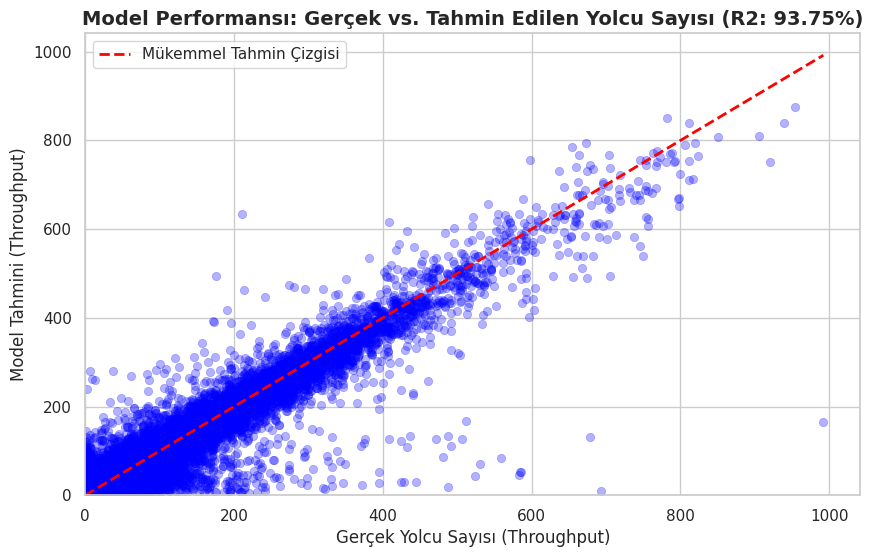

In [86]:
y_true = y_test_v5  # GERÇEK DEĞERLER
y_pred = preds_v5   # MODELİN TAHMİNLERİ

# --- GÖRSELLEŞTİRME 1---
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# Gerçek vs Tahmin Saçılım Grafiği
sns.scatterplot(x=y_true, y=y_pred, alpha=0.3, color='blue', edgecolor=None)

# Mükemmel Tahmin Çizgisi (Kırmızı Çizgi - Hedef)
# Bu çizgi üzerindeki her nokta %100 doğru tahmin demektir.
max_val = max(y_true.max(), y_pred.max())
plt.plot([0, max_val], [0, max_val], color='red', linestyle='--', linewidth=2, label='Mükemmel Tahmin Çizgisi')

plt.title(f"Model Performansı: Gerçek vs. Tahmin Edilen Yolcu Sayısı (R2: {r2_score(y_true, y_pred):.2%})", fontsize=14, fontweight='bold')
plt.xlabel("Gerçek Yolcu Sayısı (Throughput)", fontsize=12)
plt.ylabel("Model Tahmini (Throughput)", fontsize=12)
plt.legend()
plt.xlim(0, max_val*1.05)
plt.ylim(0, max_val*1.05)

plt.show()

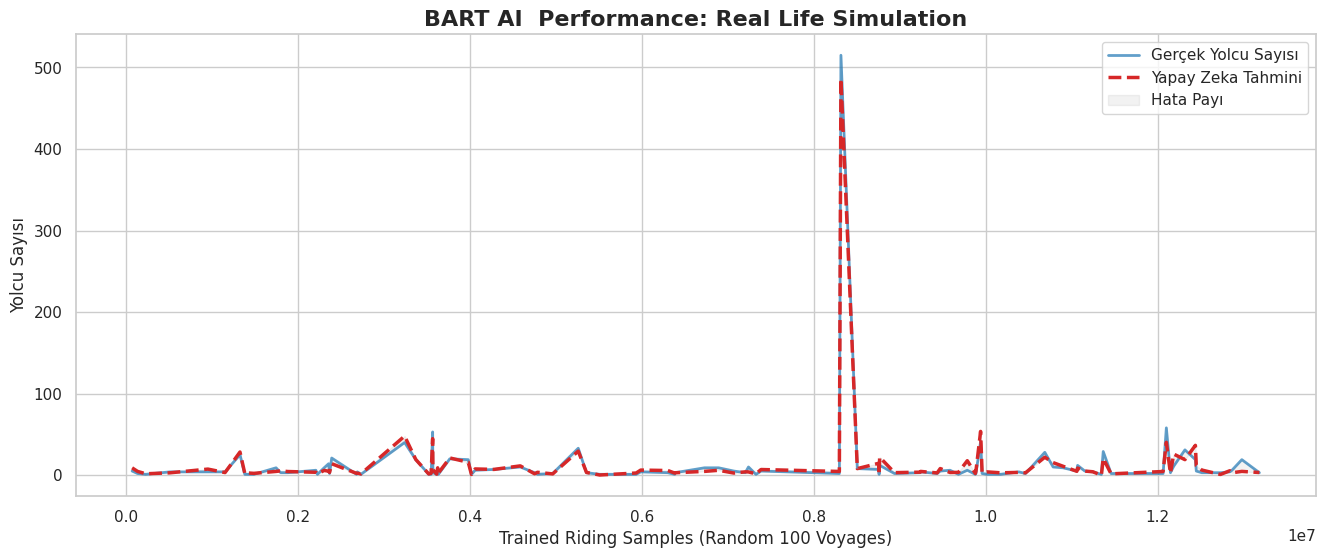

In [96]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. VERİYİ HAZIRLA
# Test setinden rastgele 100 örneği alıp karşılaştıralım.
# (Tüm veriyi çizersek karışır, 100 örnek "Zoom in" yapmak gibidir)
comparison_df = pd.DataFrame({'Gerçek': y_test_v5, 'Tahmin': preds_v5})
comparison_sample = comparison_df.sample(n=100, random_state=42).sort_index()

# 2. GÖRSELLEŞTİRME (The Money Shot 📸)
plt.figure(figsize=(16, 6))
sns.set_style("whitegrid")

# Gerçek Değerler (Mavi ve Kalın)
plt.plot(comparison_sample.index, comparison_sample['Gerçek'], label='Gerçek Yolcu Sayısı', color='#1f77b4', linewidth=2, alpha=0.7)

# Tahmin Değerleri (Kırmızı ve Kesikli)
plt.plot(comparison_sample.index, comparison_sample['Tahmin'], label='Yapay Zeka Tahmini', color='#d62728', linestyle='--', linewidth=2.5)

# Alanı Doldur (Hata payını görselleştirmek için arayı boyayalım)
plt.fill_between(comparison_sample.index, comparison_sample['Gerçek'], comparison_sample['Tahmin'], color='gray', alpha=0.1, label='Hata Payı')

plt.title("BART AI  Performance: Real Life Simulation", fontsize=16, fontweight='bold')
plt.xlabel("Trained Riding Samples (Random 100 Voyages)", fontsize=12)
plt.ylabel("Yolcu Sayısı", fontsize=12)
plt.legend(loc='upper right', frameon=True, fontsize=11)

plt.show()

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


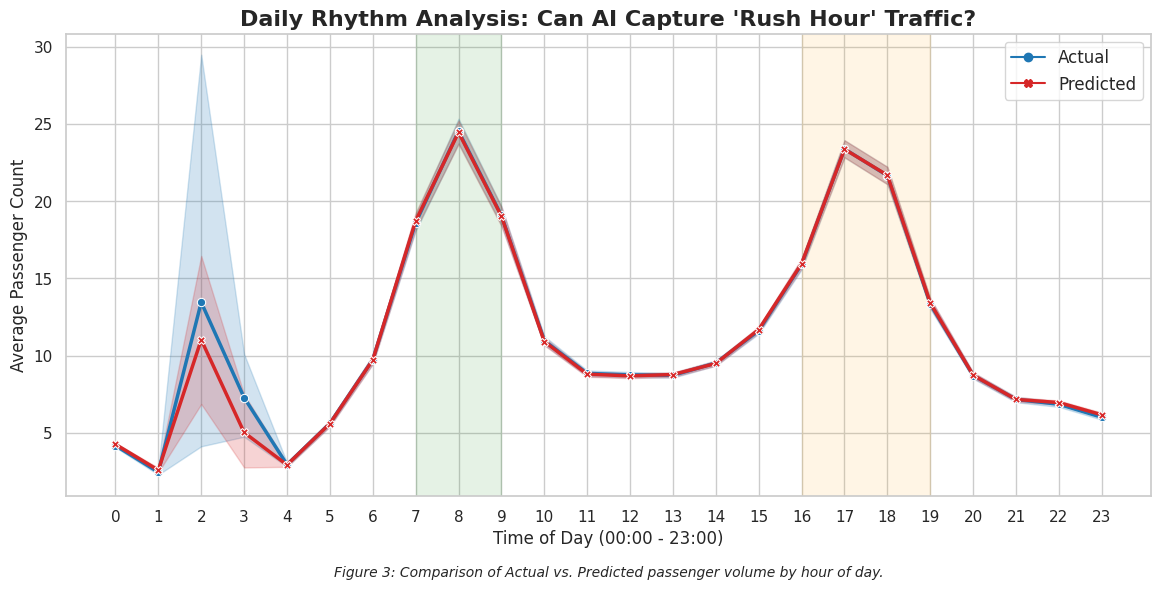

In [93]:
current_x_test = x_test_v5 
current_y_test = y_test_v5  
current_preds = preds_v5   

# Create the analysis DataFrame
analysis_df = current_x_test.copy()
analysis_df['Actual'] = current_y_test    # Renamed 'Test' to 'Actual' (More professional)
analysis_df['Predicted'] = current_preds  # Renamed 'Predict' to 'Predicted'

# Melt the data into Long Format for Seaborn
df_melted = analysis_df.melt(id_vars=['Hour'], value_vars=['Actual', 'Predicted'], 
                             var_name='Data Type', value_name='Throughput')

# 2. VISUALIZATION (Hourly Average Traffic)
plt.figure(figsize=(14, 6))
sns.set_style("whitegrid")



# Lineplot: Averages passenger counts by hour
sns.lineplot(data=df_melted, x='Hour', y='Throughput', hue='Data Type', 
             style='Data Type', markers=True, dashes=False, 
             palette={'Actual': '#1f77b4', 'Predicted': '#d62728'}, linewidth=2.5)



plt.title("Daily Rhythm Analysis: Can AI Capture 'Rush Hour' Traffic?", fontsize=16, fontweight='bold')
plt.xlabel("Time (00:00 - 23:00)", fontsize=12)
plt.ylabel("Ortalama Yolcu Sayısı", fontsize=12)
plt.xticks(range(0, 24)) 
plt.legend(title=None, fontsize=12)

# Titles and Labels (Professional English)
plt.title("Daily Rhythm Analysis: Can AI Capture 'Rush Hour' Traffic?", fontsize=16, fontweight='bold')
plt.xlabel("Time of Day (00:00 - 23:00)", fontsize=12)
plt.ylabel("Average Passenger Count", fontsize=12)
plt.xticks(range(0, 24)) 
plt.legend(title=None, fontsize=12)


# Highlight Rush Hours
plt.axvspan(7, 9, color='green', alpha=0.1, label='Morning Rush')
plt.axvspan(16, 19, color='orange', alpha=0.1, label='Evening Rush')

# Add a small annotation for context (Optional but impressive)
plt.text(0.5, -0.15, "Figure 3: Comparison of Actual vs. Predicted passenger volume by hour of day.", 
         ha='center', va='top', transform=plt.gca().transAxes, fontsize=10, style='italic')

plt.show()

<Figure size 1000x600 with 0 Axes>

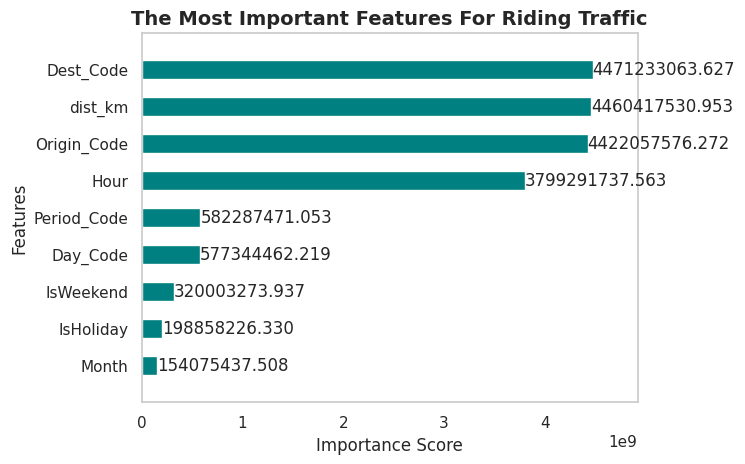

In [94]:
final_model = model_lgb_v5 

plt.figure(figsize=(10, 6))
lgb.plot_importance(final_model, max_num_features=10, importance_type='gain', height=0.5, color='teal', grid=False)
plt.title("The Most Important Features For Riding Traffic", fontsize=14, fontweight='bold')
plt.xlabel("Importance Score", fontsize=12)
plt.ylabel("Features", fontsize=12)
plt.show()

### Conclusion

#### Our developed AI model, by analyzing 2 years of historical data (13 million journeys), has managed to predict passenger traffic on the BART system with nearly 94% accuracy rate.
#### We didn't use our all data since it could be trouble for our Ram but after adding more rows, we didn't see that this step increased our R2. Also we need special events and weather conditions to make more accurate predictions while evaulating our model.
#### Also we could add Lag Features (Gecikmeli Değişkenler)